# Análisis de Campañas de Marketing para Predecir Contratación de Depósitos

## Objetivo
Predecir la efectividad de las campañas de marketing telefónicas realizadas por una empresa fintech, para identificar qué factores influyen en que un cliente contrate o no un depósito.

## Datos Utilizados
- **Período de análisis:** Mayo 2018 – Noviembre 2020.
- **Tipo de interacción:** Llamadas telefónicas.

### Desafíos
- **Datos desbalanceados:** La mayoría de los clientes no contratan el depósito.
- **Falta de variable de fecha completa:** Los datos están ordenados por fecha, pero no incluyen la fecha exacta de cada llamada.

## Modelo Propuesto: XGBoost + RandomizedSearchCV + ADASYN

### XGBoost
- **Descripción:** Potente algoritmo de clasificación basado en árboles de decisión que maneja bien grandes volúmenes de datos y problemas con desbalance de clases.
- **Ventaja:** Alta precisión y rapidez en tareas de predicción.

### RandomizedSearchCV
- **Descripción:** Permite encontrar los mejores hiperparámetros de forma eficiente sin hacer una búsqueda exhaustiva.
- **Ventaja:** Optimiza el modelo sin necesidad de recorrer todo el espacio de hiperparámetros.

### ADASYN
- **Descripción:** Técnica utilizada para balancear el dataset mediante la generación de muestras sintéticas de la clase minoritaria.
- **Ventaja:** Mejora el rendimiento del modelo en clases desbalanceadas.

In [59]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import missingno as msno

# Expresiones regulares
import re
import warnings
warnings.filterwarnings('ignore')

import os

# Preprocesamiento de datos y ML
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from scipy.stats import randint, uniform
from imblearn.over_sampling import ADASYN
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from tqdm import tqdm

# Evaluacion
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [60]:
path = 'bank-additional_bank-additional-full.csv'
delimiter = ';'

data = pd.read_csv(path, delimiter=delimiter)

# Mostramos las primeras filas del DataFrame para verificar la carga de datos
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


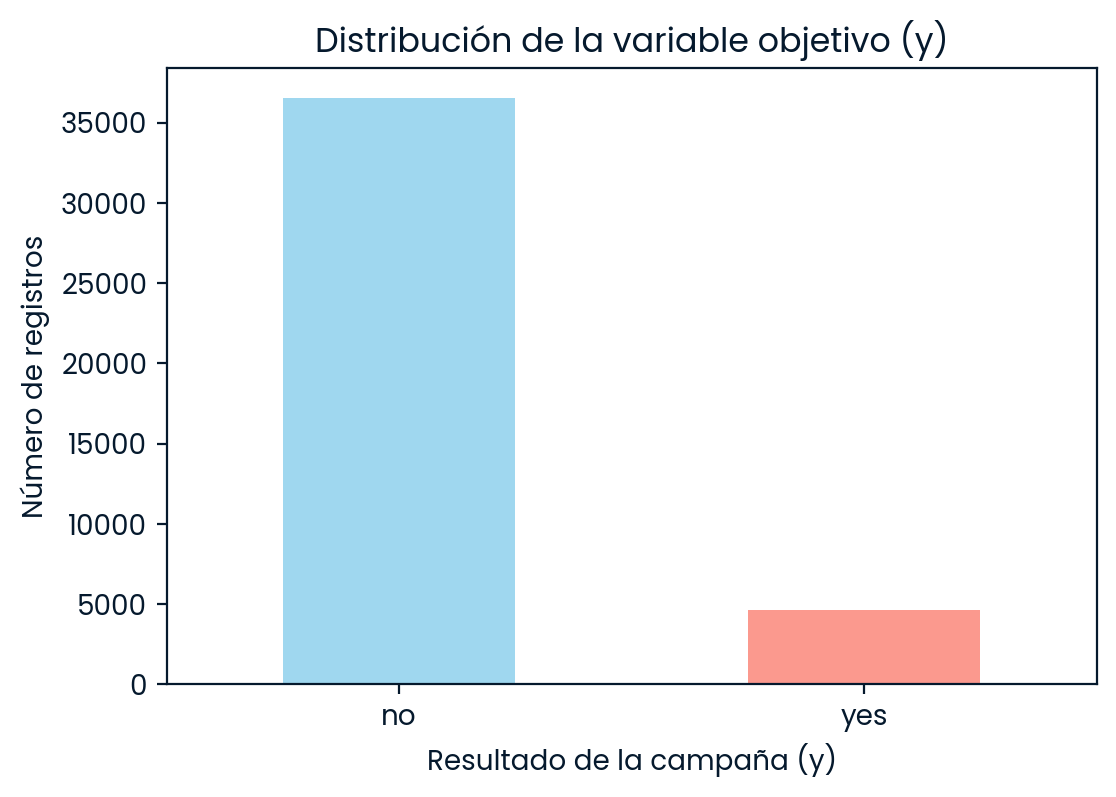

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [86]:
# Distribución de la variable objetivo ('y')
y_distribution = data['y'].value_counts(normalize=True) * 100  # Porcentaje
y_counts = data['y'].value_counts()  # Conteo absoluto

# Gráfico de la distribución
plt.figure(figsize=(6, 4))
y_counts.plot(kind='bar', color=['skyblue', 'salmon'], alpha=0.8)
plt.title('Distribución de la variable objetivo (y)')
plt.xlabel('Resultado de la campaña (y)')
plt.ylabel('Número de registros')
plt.xticks(rotation=0)
plt.show()

# Resultados en porcentaje
y_distribution

# Estudio de las variables

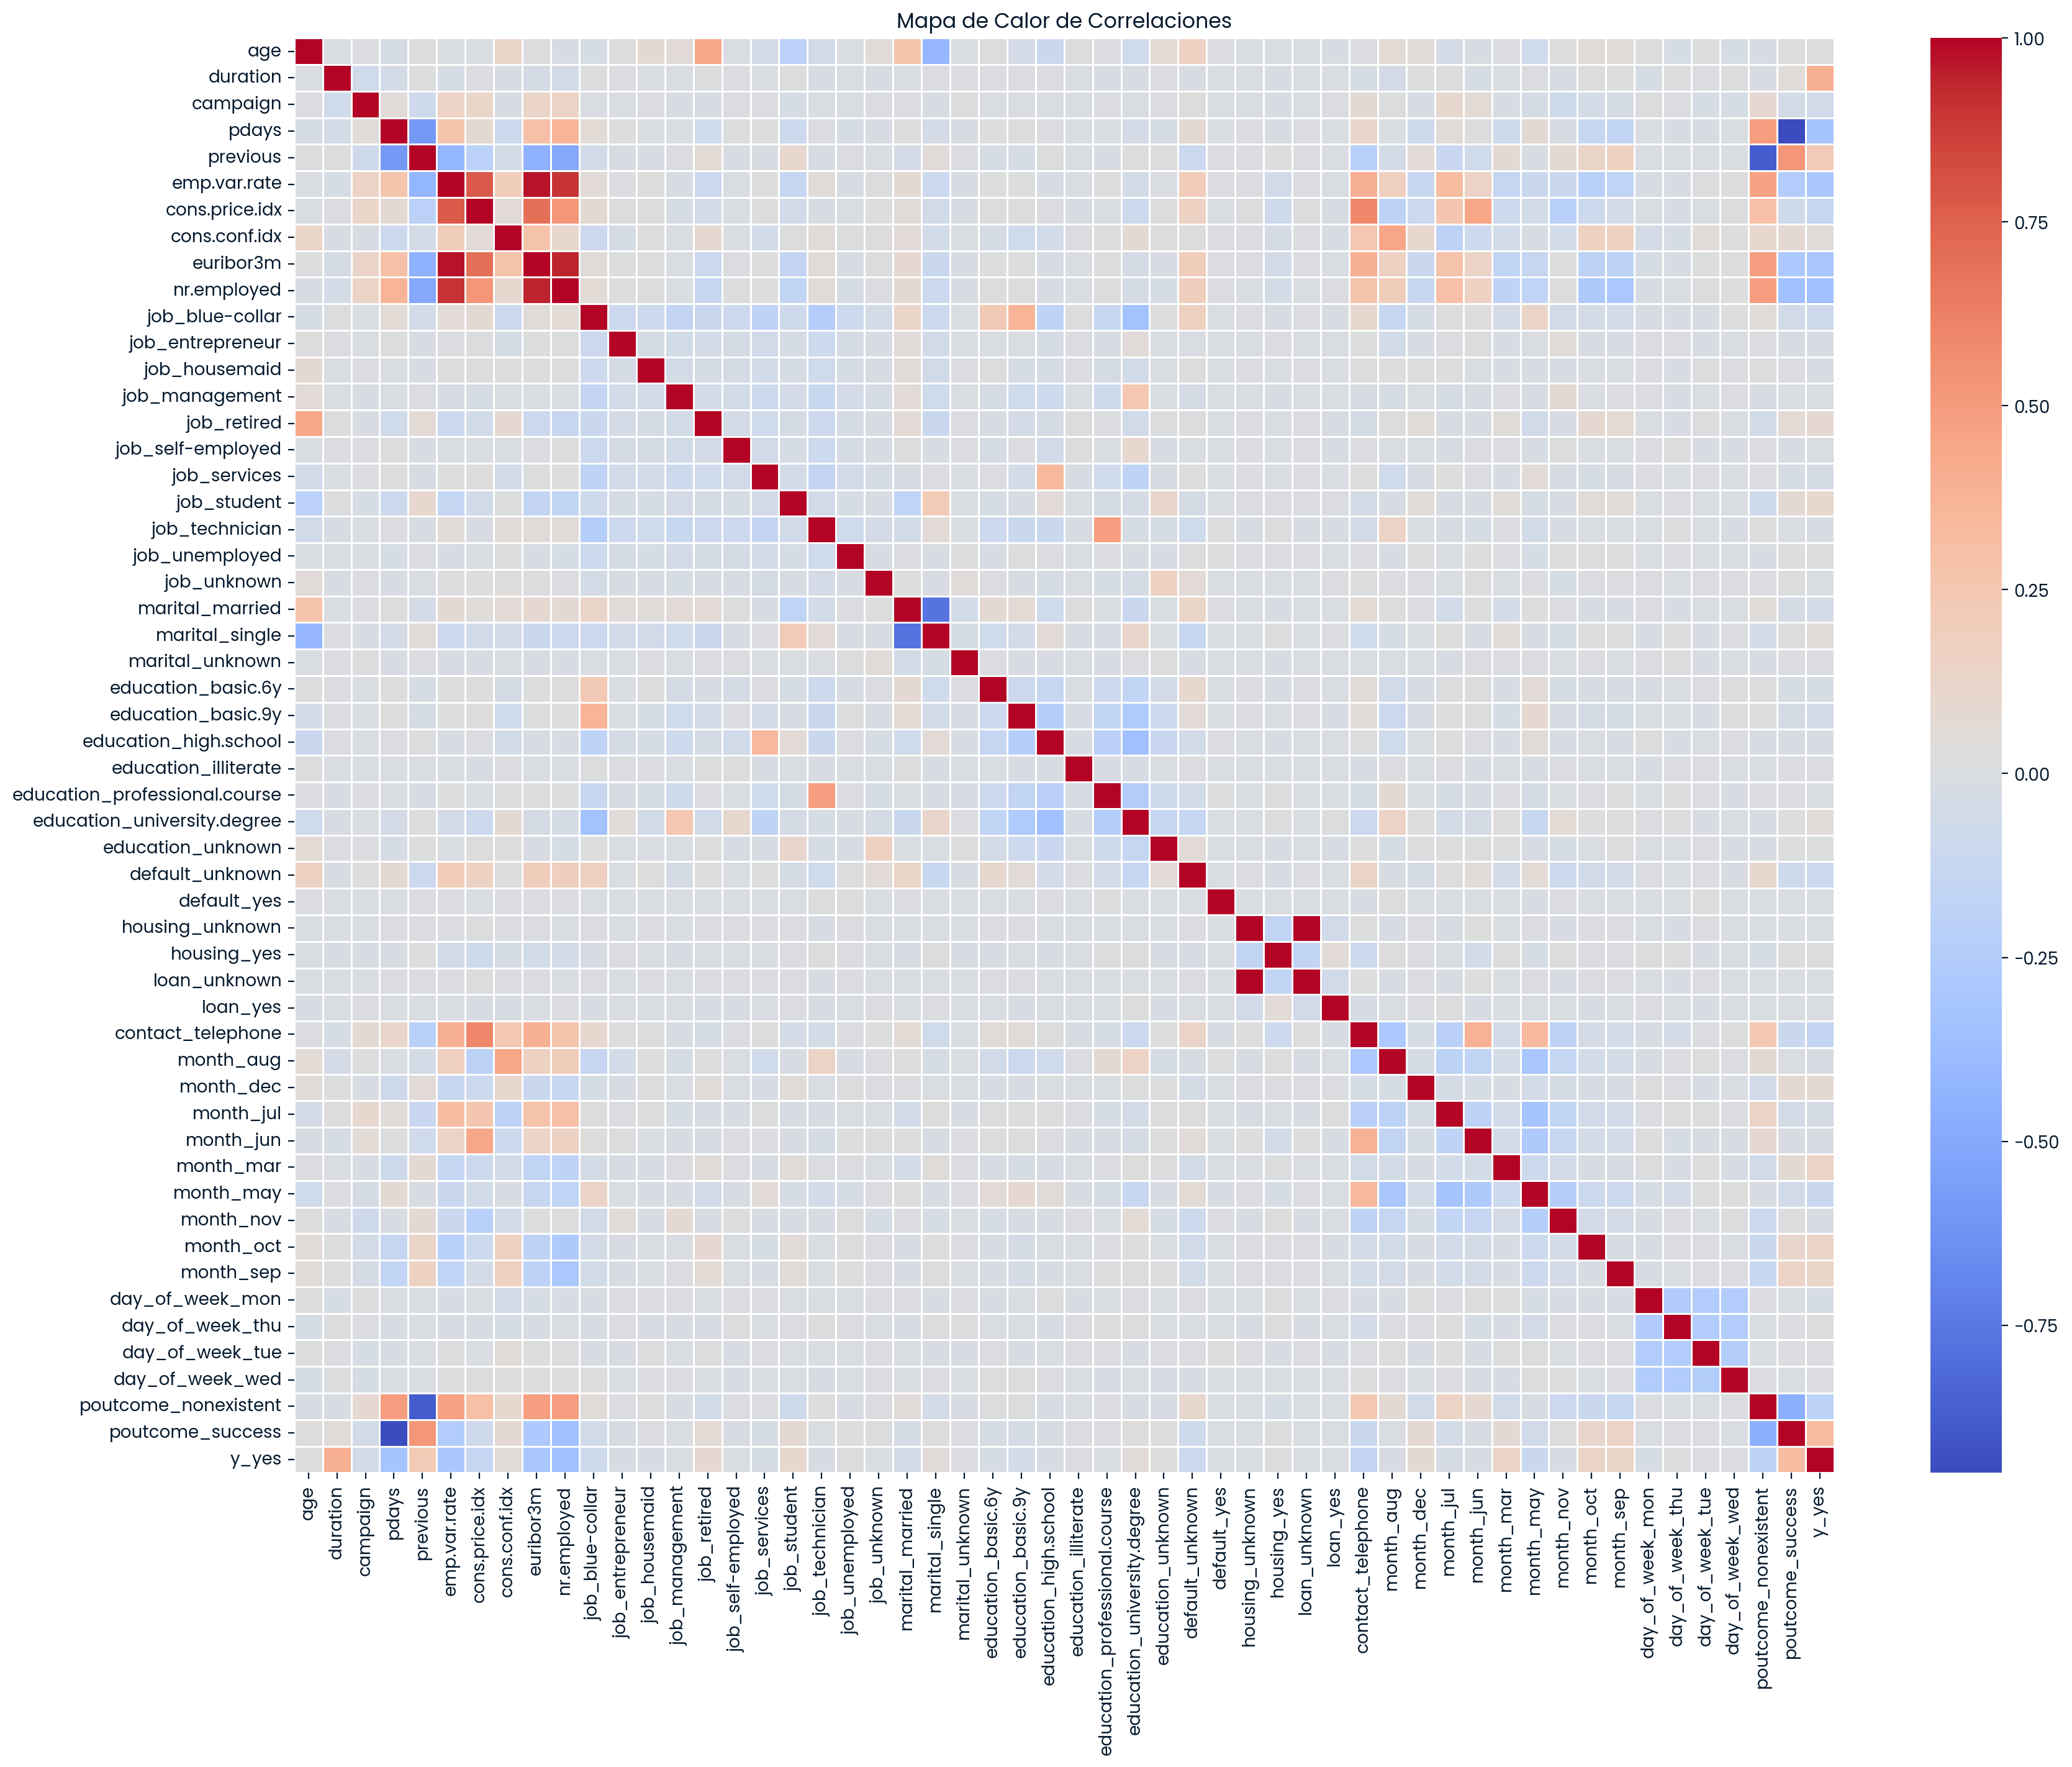

In [61]:
# Convertimos todas las variables categóricas a variables dummy, sin cambiar 'y'
data_dum = pd.get_dummies(data, drop_first=True)

# Calculamos la matriz de correlación
corr_matrix = data_dum.corr()

# Grafico del mapa de calor
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones")
plt.show()


### Variables más correlacionadas:

- **duration (0.41)**: Relación positiva moderada con la variable objetivo `y`. Podría ser una variable clave para predecir si un cliente aceptará el depósito.
- **poutcome_success (0.32)**: Relación moderada, lo que indica que el resultado previo del contacto tiene algo de influencia sobre la aceptación.
- **previous (0.23)**: Una correlación positiva moderada, lo que sugiere que los clientes con más interacciones previas podrían estar más dispuestos a aceptar el depósito.

### Variables ligeramente correlacionadas:

- **month_mar (0.14)**, **month_oct (0.14)**, **month_sep (0.13)**: Los meses en los que se realizan las campañas de contacto tienen una correlación positiva baja, lo que sugiere que el mes podría tener alguna influencia, pero no es un factor principal.
- **job_student (0.09)**, **job_retired (0.09)**: Las personas que son estudiantes o jubilados tienen una correlación baja con la aceptación, lo que sugiere que su probabilidad de aceptar es relativamente baja, pero no es completamente irrelevante.

### Variables con baja o casi nula correlación:

Varias variables tienen correlaciones cercanas a 0 (como `education_unknown`, `job_unemployed`, `day_of_week_thu`, `housing_yes`, entre otras). Estas variables podrían no ser útiles para el modelo, ya que no aportan información significativa para predecir si un cliente aceptará el depósito.

### Variables menos correlacionadas:

- **emp.var.rate (-0.30)**, **euribor3m (-0.31)**, **pdays (-0.32)**: Tienen correlaciones negativas moderadas, lo que sugiere que a medida que estas variables aumentan, la probabilidad de que el cliente acepte el depósito disminuye.
- **nr.employed (-0.35)**: La correlación negativa más fuerte con `y`. Esto podría indicar que más empleados en una empresa o región podría estar asociado con una menor probabilidad de aceptación del depósito.

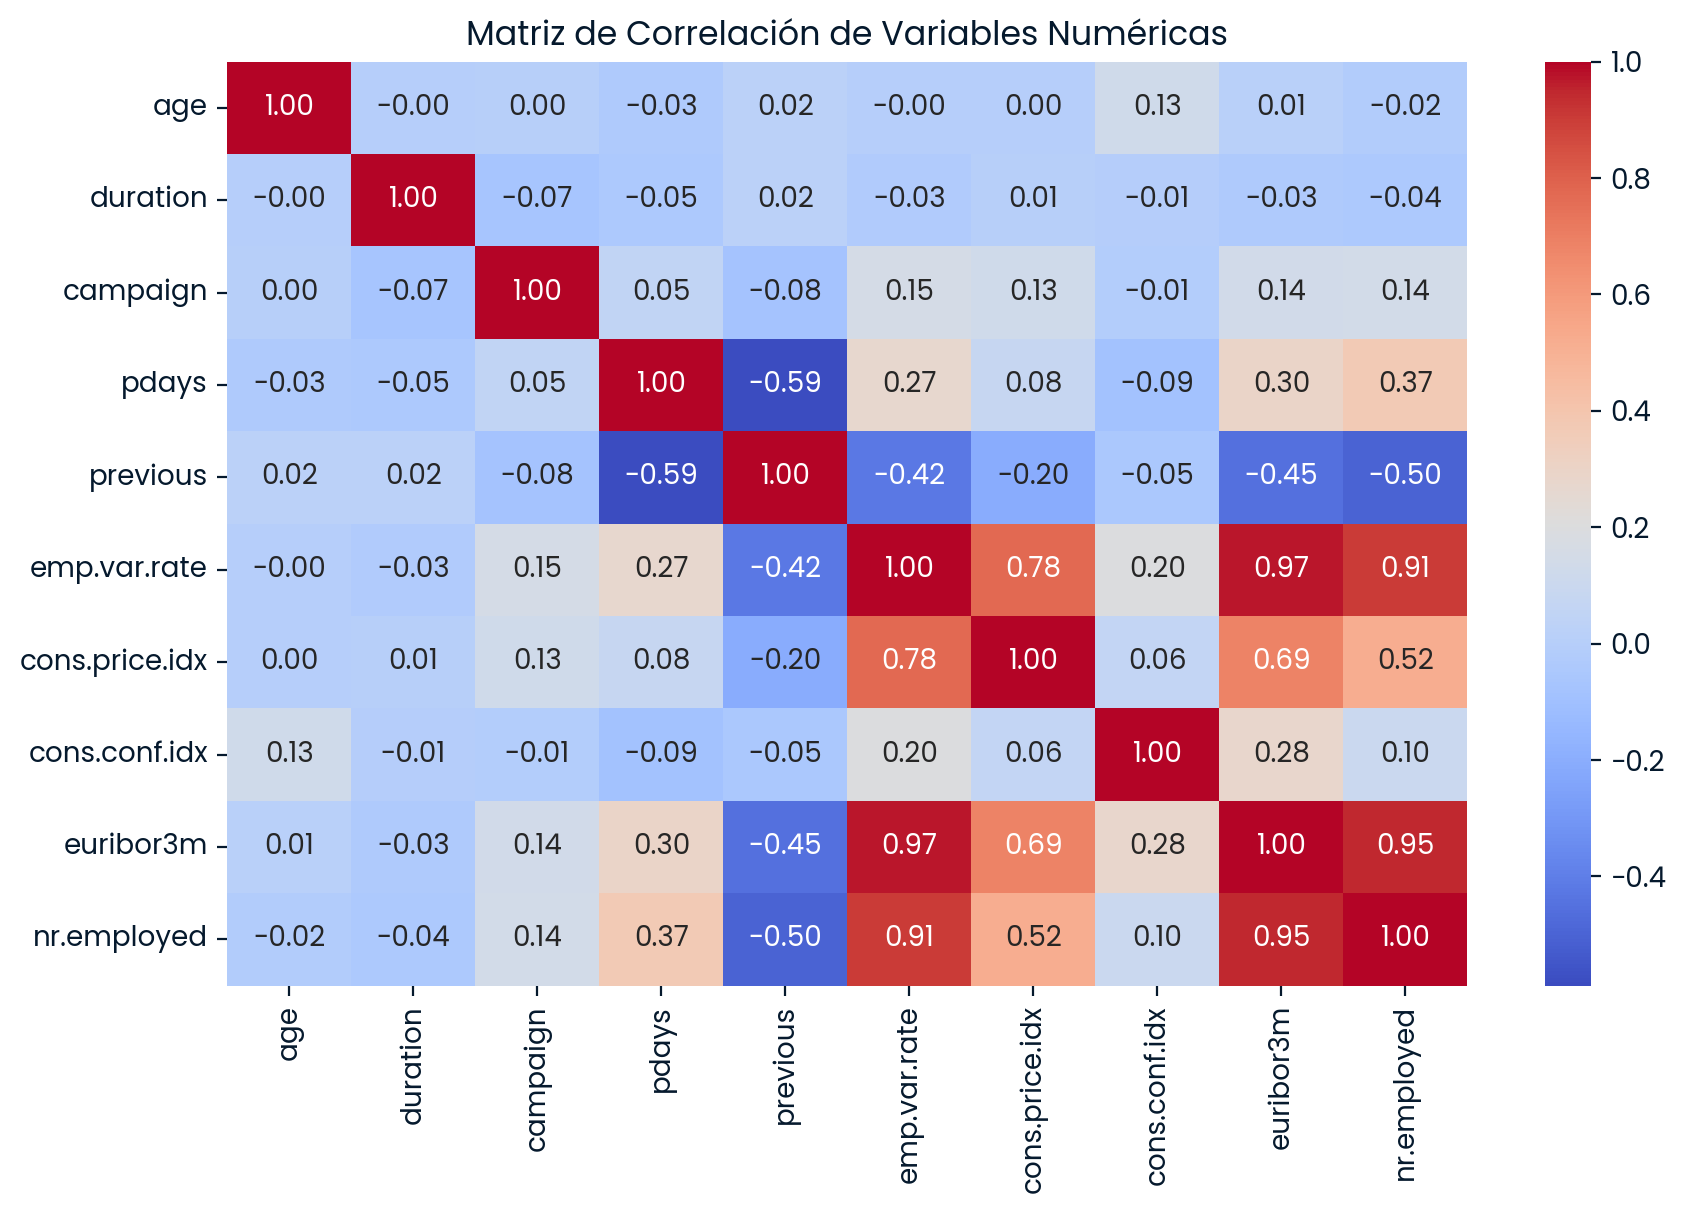

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


In [62]:
# Seleccionamos las columnas numéricas del DataFrame 'data'
numeric_vars = data.select_dtypes(include='number').columns

# Configuramos el tamaño de la figura para el heatmap
plt.figure(figsize=(10, 6))

# Creamos un heatmap de la matriz de correlación de las variables numéricas
heatmap = sns.heatmap(data[numeric_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")

# Mostramos el heatmap
plt.show()

# Calculamos la matriz de correlación de las variables numéricas
correlation_matrix = data[numeric_vars].corr()

# Mostramos la matriz de correlación
correlation_matrix

La matriz de correlación nos ayuda a identificar las relaciones entre las variables, y a continuación te explico algunas observaciones clave para tu análisis:

- **Euribor3m y nr.employed** tienen una correlación muy alta (**0.95**), lo que sugiere que estos dos indicadores están muy relacionados. Si uno cambia, el otro probablemente también lo hará. Esta relación es importante, ya que podría ser útil para hacer predicciones y se podría considerar mantener solo una de estas variables en el modelo.

- **Emp.var.rate y Euribor3m** también tienen una correlación muy fuerte (**0.97**), lo que implica que ambos se mueven en la misma dirección. Esto es útil porque si hay un cambio en el Euribor, probablemente también se refleje en el emp.var.rate, por lo que podríamos optar por usar una sola de ellas.

- **Pdays y previous** tienen una correlación negativa (**-0.59**). Esto sugiere que cuando los valores de pdays son bajos (es decir, los días desde el último contacto son pocos), también tienden a tener un número bajo de contactos previos. Esta relación podría ayudar a entender cómo el tiempo desde el último contacto influye en el número de intentos previos.

- **Duración de la campaña (duration) y campaña (campaign)** tienen una correlación baja (**-0.07**). Esto indica que no existe una relación fuerte entre la duración y la cantidad de intentos de contacto, lo que sugiere que ambos factores pueden tener un impacto diferente en la predicción.

- **Emp.var.rate y cons.price.idx** tienen una correlación bastante alta (**0.77**), lo que indica que ambos se mueven de manera similar. Esta relación podría ser valiosa para comprender las tendencias macroeconómicas que impactan las decisiones de los clientes.

En resumen, algunas variables están fuertemente correlacionadas y podríamos considerar simplificar el modelo eliminando o combinando estas variables para evitar redundancia.

## Agrupación de Clientes por Percentiles de Edad

Los percentiles de edad se utilizan para agrupar a los clientes en rangos de edad de manera que cada grupo tenga aproximadamente la misma cantidad de personas. Esto ayuda a entender mejor cómo la edad influye en la probabilidad de aceptar un depósito.

### Ventajas de Usar Percentiles

Al dividir la edad en rangos de percentiles (por ejemplo, "17-30", "31-34", etc.), no estamos simplemente usando rangos fijos, sino que agrupamos a los clientes de forma equitativa según su edad. Esto permite que el modelo vea variaciones en la aceptación de depósitos entre diferentes edades sin que los grupos estén desbalanceados.

### Objetivo

La idea es captar patrones dentro de cada grupo de edad que podrían estar relacionados con la probabilidad de aceptación, ya que algunos grupos de edad pueden tener comportamientos de compra o interés distintos.

In [63]:
# Definimos los percentiles para los grupos de edades
percentiles = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]  # Los percentiles deben estar en el intervalo [0, 1]
age_bins = [data['age'].quantile(p) for p in percentiles]

# Etiquetamos para los grupos (con un grupo adicional para mayores de 70)
age_labels = [f'{int(age_bins[i])}-{int(age_bins[i+1])-1}' for i in range(len(age_bins)-1)]
age_labels[-1] = '70+'  # El último grupo será para mayores de 70

# Asignamos a la columna 'age_group_quantile'
data['age_group_quantile'] = pd.cut(data['age'], bins=age_bins, labels=age_labels, include_lowest=True)

# Verificamos valores al azar para ver de la transformación
print(data[['age', 'age_group_quantile']].sample(15))

       age age_group_quantile
10927   25              17-30
24797   44              41-48
28915   34              31-34
23058   46              41-48
4110    38              35-40
2684    51              49-54
10891   32              31-34
36664   27              17-30
30641   34              31-34
15035   48              41-48
4106    41              35-40
4906    44              41-48
7429    33              31-34
1500    33              31-34
33048   46              41-48


## Creación de las variables `duration_campaign_ratio` y `previous_pdays_ratio`

Estas variables ayudarán a entender mejor el comportamiento de los clientes en las campañas de marketing.

### 1. `duration_campaign_ratio`

Esta variable mide la relación entre la duración de la llamada y el número de contactos realizados en la campaña. Se calcula como:

```
duration_campaign_ratio = duración de la llamada / número de contactos en la campaña
```

**Significado:**

- Si la duración de la llamada es larga pero el número de contactos es bajo, podría indicar que el cliente está mostrando un interés mayor y, por lo tanto, tiene una mayor probabilidad de aceptar el depósito.
- Esta variable proporciona un contexto sobre cómo el cliente ha interactuado en relación con los esfuerzos de contacto, lo que podría ser una señal de su nivel de interés.

### 2. `previous_pdays_ratio`

Esta variable mide la relación entre el número de contactos previos y los días desde el último contacto. Se calcula como:

```
previous_pdays_ratio = número de contactos previos / días desde el último contacto
```

**Significado:**

- Si un cliente ha sido contactado en muchas ocasiones dentro de un corto período, su familiaridad con la campaña podría aumentar, lo que podría hacerle más propenso a aceptar el depósito.
- La variable ayuda a entender mejor el nivel de repetición de la interacción con el cliente, lo cual puede influir en su comportamiento de aceptación.

Ambas variables añaden contexto sobre la interacción con el cliente, lo que puede ayudar a mejorar la predicción de si aceptará o no el depósito.

In [64]:
# Creamos nuevas variables derivadas
data['duration_campaign_ratio'] = data['duration'] / (data['campaign'] + 1)
data['previous_pdays_ratio'] = data['previous'] / (data['pdays'] + 1)

# Verificamos las primeras filas para asegurar que las nuevas variables fueron creadas correctamente
print(data[['duration', 'campaign', 'previous', 'pdays', 'duration_campaign_ratio', 'previous_pdays_ratio']].head())

   duration  campaign  previous  pdays  duration_campaign_ratio  \
0       261         1         0    999                    130.5   
1       149         1         0    999                     74.5   
2       226         1         0    999                    113.0   
3       151         1         0    999                     75.5   
4       307         1         0    999                    153.5   

   previous_pdays_ratio  
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.0  


### Variables Categóricas:

- **`age_group_quantile`**: Agrupar la edad permite capturar diferencias en las decisiones financieras por grupos de edad, facilitando una mejor generalización.
- **`job`**, **`marital`**, **`education`**, **`housing`**, **`loan`**: Estas variables reflejan el perfil socioeconómico del cliente, lo que influye en su capacidad o disposición para aceptar un depósito.
- **`contact`**, **`month`**, **`poutcome`**: El medio de contacto y el mes reflejan el contexto de la campaña, mientras que el resultado anterior ayuda a medir la efectividad de la interacción pasada.

### Variables Numéricas:

- **`duration`**, **`campaign`**: La duración del contacto y el número de interacciones reflejan el interés del cliente y su disposición a aceptar la oferta.
- **`euribor3m`**, **`emp.var.rate`**, **`cons.price.idx`**, **`cons.conf.idx`**: Estas variables económicas impactan las decisiones de inversión y ahorro, influyendo en la disposición del cliente para aceptar productos financieros.
- **`duration_campaign_ratio`**, **`previous_pdays_ratio`**: Estas relaciones nos indican la eficiencia de la campaña y la antigüedad de los contactos previos, lo que puede ayudar a predecir la probabilidad de aceptación.

En conjunto, estas variables cubren aspectos clave del comportamiento del cliente y el entorno económico que influyen en la aceptación de un depósito, lo que puede mejorar el desempeño del modelo.

# División de datos y visualización de la distribución original

In [65]:
# Variables de entrada
target = 'y'

# Variables categóricas
categorical_vars = ['age_group_quantile', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Variables numéricas (actualizadas)
numeric_vars = ['duration', 'campaign', 'euribor3m', 'emp.var.rate', 'cons.price.idx',
                'cons.conf.idx', 'duration_campaign_ratio', 'previous_pdays_ratio']

# Revisamos las variables antes de usarlas en el modelo
print("Variables categóricas:", categorical_vars)
print("Variables numéricas:", numeric_vars)


Variables categóricas: ['age_group_quantile', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numéricas: ['duration', 'campaign', 'euribor3m', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'duration_campaign_ratio', 'previous_pdays_ratio']


In [66]:
# Seleccionamos variables de entrada y target
X = data[categorical_vars + numeric_vars]
y = data[target].map({'yes': 1, 'no': 0})  # Convertimos 'yes/no' a 1/0

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Vemos la distribución original de la clase en el entrenamiento
print("Distribución original en entrenamiento:", Counter(y_train))

Distribución original en entrenamiento: Counter({0: 25583, 1: 3248})


# Creación del preprocesador y definición del pipeline

In [67]:
# Creamos el preprocesador para variables numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', StandardScaler())
         ]),
         numeric_vars),
        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(drop='first', sparse_output=False))
         ]),
         categorical_vars)
    ]
)

El uso de **ADASYN** en el pipeline ayuda a resolver el desbalance de clases, donde "no" tiene un 88.7% y "yes" solo un 11.3%. **ADASYN** genera ejemplos sintéticos para la clase minoritaria, mejorando la capacidad del modelo para predecirla. Al equilibrar las clases con `sampling_strategy=0.5`, el modelo aprende mejor y evita el sesgo hacia la clase mayoritaria, lo que mejora métricas como el **F1-score**.

In [68]:
# Creamos el objeto ADASYN para balancear las clases (se aplicará dentro de la pipeline)
adasyn = ADASYN(sampling_strategy=0.5, random_state=42)

# Creamos el pipeline con preprocesamiento, ADASYN y XGBoost
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('adasyn', adasyn),
    ('classifier', XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='mlogloss'))
])

# Configuración y entrenamiento con RandomizedSearchCV

In [69]:
# Definimos el espacio de búsqueda de hiperparámetros
param_dist = {
    'classifier__n_estimators': randint(100, 700),     # Número de árboles
    'classifier__learning_rate': uniform(0.01, 0.4),     # Tasa de aprendizaje
    'classifier__max_depth': randint(3, 20),             # Profundidad máxima de los árboles
    'classifier__min_child_weight': randint(1, 20),      # Peso mínimo de los hijos
    'classifier__gamma': uniform(0, 0.5),                # Controla la complejidad del modelo
    'classifier__subsample': uniform(0.6, 1.0),          # Fracción de muestras utilizadas en cada árbol
    'classifier__colsample_bytree': uniform(0.6, 1.0),   # Proporción de características utilizadas por cada árbol
    'classifier__scale_pos_weight': randint(10, 100),    # Ajuste para clases desbalanceadas (peso para "YES")
    'adasyn__sampling_strategy': uniform(0.1, 1.0)         # Estrategia de muestreo para ADASYN
}

In [76]:
# Definir la búsqueda de hiperparámetros
random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist, 
    n_iter=500,  
    scoring='f1',  
    cv=5,  
    random_state=42, 
    n_jobs=-1  
)

In [77]:
# Entrenamiento
random_search.fit(X_train, y_train)

# Obtenemos el mejor modelo
best_model = random_search.best_estimator_

# Imprimir los mejores hiperparámetros
print("Mejores hiperparámetros encontrados:")
for key, value in sorted(random_search.best_params_.items()):
    print(f"{key}: {value}")

Mejores hiperparámetros encontrados:
adasyn__sampling_strategy: 0.17002970574747103
classifier__colsample_bytree: 0.609485433628498
classifier__gamma: 0.026341917988614294
classifier__learning_rate: 0.04541736424544726
classifier__max_depth: 14
classifier__min_child_weight: 16
classifier__n_estimators: 539
classifier__scale_pos_weight: 19
classifier__subsample: 0.6916993351114301


# Predicciones y ajuste del umbral para maximizar el F1-score


In [78]:
# Realizamos predicciones en el conjunto de prueba 
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Ajustamos el umbral para maximizar el F1-score
best_threshold = 0.5
best_f1 = 0
thresholds = np.linspace(0.2, 0.8, 100)  # Generamos 100 valores entre 0.2 y 0.8
for threshold in thresholds:
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    current_f1 = f1_score(y_test, y_pred_adjusted)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print("Mejor umbral encontrado:", best_threshold)
print("F1-score con el umbral ajustado:", best_f1)

# Aplicamos el mejor umbral para obtener las predicciones finales
y_pred = (y_pred_proba >= best_threshold).astype(int)

Mejor umbral encontrado: 0.7212121212121212
F1-score con el umbral ajustado: 0.6447602131438721


Mejor umbral: 0.7212121212121212
F1-score: 0.6447602131438721
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94     10965
           1       0.55      0.78      0.64      1392

    accuracy                           0.90     12357
   macro avg       0.76      0.85      0.79     12357
weighted avg       0.92      0.90      0.91     12357

Confusion Matrix:
 [[10068   897]
 [  303  1089]]
ROC AUC: 0.9443068593382288


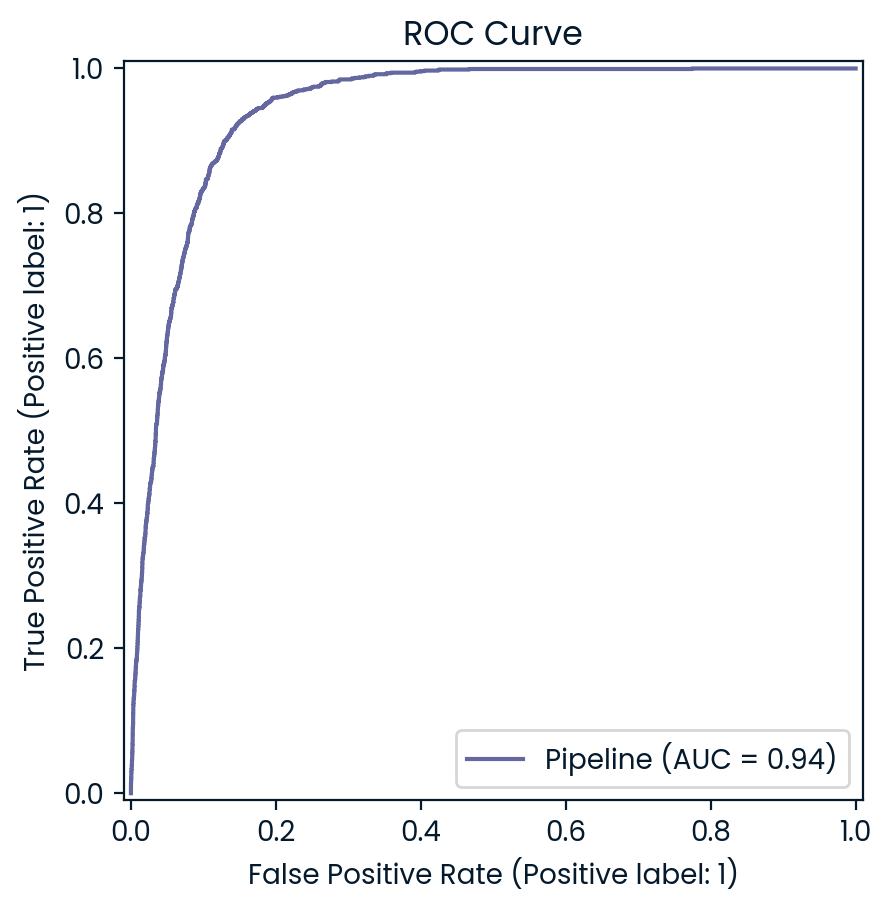

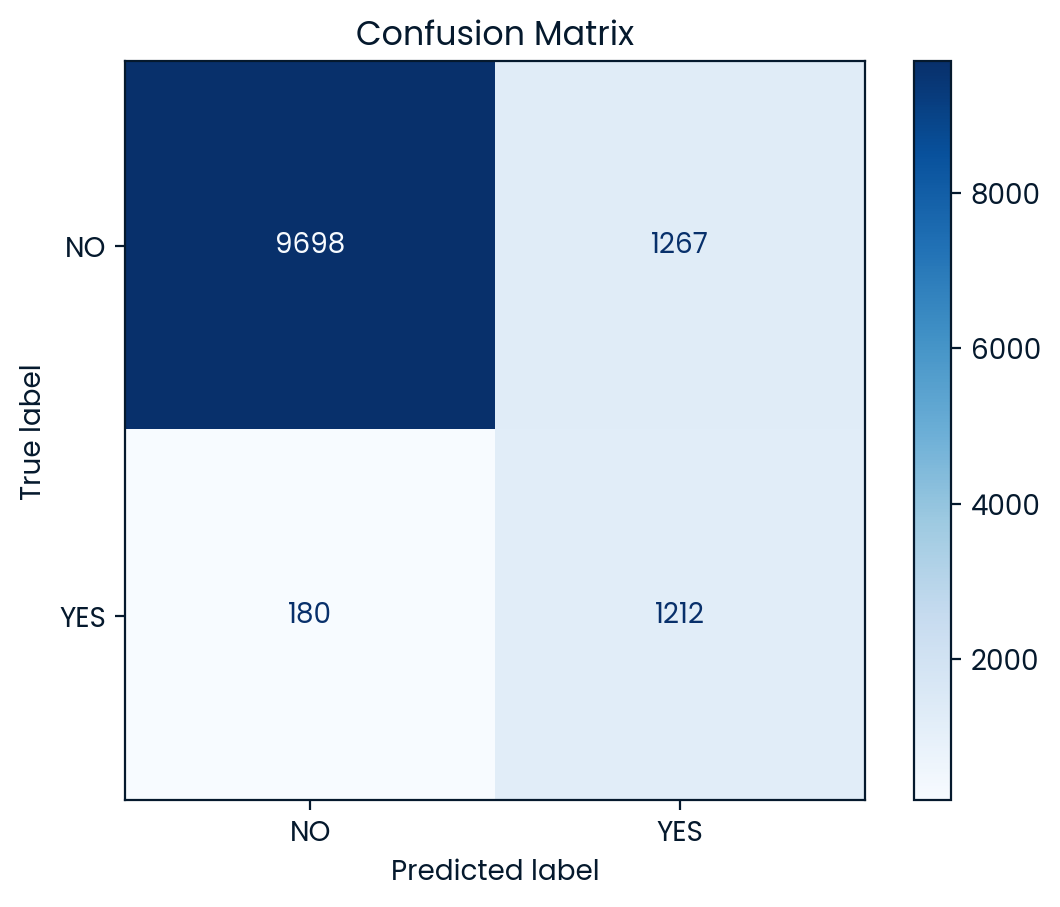

In [85]:
# Evaluamos el modelo
classification_report_result = classification_report(y_test, y_pred)
confusion_matrix_result = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Mostramos los resultados
print("Mejor umbral:", best_threshold)
print("F1-score:", best_f1)
print("Classification Report:\n", classification_report_result)
print("Confusion Matrix:\n", confusion_matrix_result)
print("ROC AUC:", roc_auc)

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=['NO', 'YES'], cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Memoria del Modelo: XGBoost + RandomizedSearchCV + ADASYN

## Objetivo
El objetivo principal de este proyecto es predecir si un cliente aceptará o no un depósito a partir de los datos históricos de interacciones con campañas de marketing de una empresa fintech. Para ello, se busca identificar patrones, tendencias y factores que influyen en la decisión de los clientes a través de un modelo predictivo. Este modelo ayudará a la empresa a optimizar sus futuras campañas y tomar decisiones estratégicas más informadas.

## Descripción del Modelo
El modelo utilizado para la predicción es un **XGBoost**, un algoritmo de boosting basado en árboles de decisión. Este modelo ha sido seleccionado por su capacidad de manejar grandes volúmenes de datos y su alta eficiencia en la clasificación binaria. Las clases a predecir son:

- **Clase 0 (NO)**: El cliente no acepta el depósito.
- **Clase 1 (YES)**: El cliente acepta el depósito.

Además, se aplicó la técnica **ADASYN** (Adaptive Synthetic Sampling) para manejar el desbalanceo de clases, ya que la clase de clientes que aceptan el depósito es mucho menor que la clase que no lo acepta.

## Preprocesamiento de Datos

### Análisis Adicional y Variables Derivadas
Se introdujeron nuevas variables para captar mejor el comportamiento de los clientes:

1. **Agrupación por Percentiles de Edad**:
   - Los percentiles de edad fueron utilizados para agrupar a los clientes en rangos equitativos según su edad, lo que permite observar cómo la edad influye en la probabilidad de aceptar un depósito sin sesgar los grupos.
   - **Ventaja**: Evita la distorsión de los rangos fijos y mejora la capacidad del modelo para identificar patrones según el grupo etario.

2. **Nuevas Variables Derivadas**:
   - `duration_campaign_ratio`: Relación entre la duración de la llamada y el número de contactos en la campaña.
   - `previous_pdays_ratio`: Relación entre el número de contactos previos y los días desde el último contacto.

Estas variables proporcionan un mejor entendimiento de la interacción de los clientes con las campañas y ayudan a predecir con mayor precisión si un cliente aceptará el depósito.

## Variables
- **Variables Categóricas**: `age_group_quantile`, `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month`, `poutcome`.
- **Variables Numéricas**: `duration`, `campaign`, `euribor3m`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `duration_campaign_ratio`, `previous_pdays_ratio`.

## Imputación de Datos Faltantes
- **Variables Numéricas**: Se utilizó la media para imputar los valores faltantes.
- **Variables Categóricas**: Se utilizó el valor más frecuente para completar los valores faltantes.

## Escalado de Variables Numéricas
Se aplicó **StandardScaler** para normalizar las variables numéricas, asegurando que todas las variables tuvieran una escala similar, lo que es importante para los modelos de machine learning como XGBoost.

## Codificación de Variables Categóricas
Las variables categóricas fueron convertidas en variables dummy utilizando **OneHotEncoder**, lo que permite que el modelo pueda entender las variables de tipo texto.

## Balanceo de Clases
Dado que las clases estaban desbalanceadas, se utilizó **ADASYN** para generar ejemplos sintéticos de la clase minoritaria (clientes que aceptan el depósito). Esto ayudó a mejorar el desempeño del modelo en la predicción de esta clase, sin perder información relevante de la clase mayoritaria.

## Entrenamiento del Modelo
El modelo fue entrenado utilizando XGBoost con los mejores hiperparámetros obtenidos mediante **RandomizedSearchCV**:

**Mejores Hiperparámetros**:
- `adasyn__sampling_strategy`: 0.17
- `classifier__colsample_bytree`: 0.61
- `classifier__gamma`: 0.03
- `classifier__learning_rate`: 0.05
- `classifier__max_depth`: 14
- `classifier__min_child_weight`: 16
- `classifier__n_estimators`: 539
- `classifier__scale_pos_weight`: 19
- `classifier__subsample`: 0.69

Estos hiperparámetros fueron ajustados para optimizar el rendimiento del modelo y asegurar una buena generalización a datos no vistos.

## Evaluación del Modelo
El rendimiento del modelo fue evaluado utilizando diversas métricas de clasificación:

```
               precision    recall  f1-score   support
           0       0.97      0.92      0.94     10,965
           1       0.55      0.78      0.64      1,392

    accuracy                           0.90     12,357
   macro avg       0.76      0.85      0.79     12,357
weighted avg       0.92      0.90      0.91     12,357
```

**Precision y Recall**:
- **Clase 0 (NO)**: Precision: 0.97, Recall: 0.92, F1-score: 0.94 
- **Clase 1 (YES)**: Precision: 0.55, Recall: 0.78, F1-score: 0.64 

**Matriz de Confusión**:
```
[
  [10068,  897],
  [  303, 1089]
]
```

- **ROC AUC**: 0.94

### Dificultades para Mejorar el F1-Score de la Clase YES
Aunque el modelo alcanza un F1-score de 0.64 para la clase "YES", es importante destacar que:

- **Desbalance inherente**: La proporción extremadamente baja de la clase "YES" limita la cantidad de información disponible para que el modelo aprenda patrones robustos.
- **Variabilidad en el comportamiento del cliente**: Las características que influyen en la decisión de aceptar un depósito pueden ser muy sutiles y estar influenciadas por factores externos difíciles de capturar.
- **Ruido en los datos**: Los datos históricos de campañas de marketing pueden contener ruido o inconsistencias que afectan la precisión del modelo.
- **Límites de la técnica**: Incluso con técnicas avanzadas de balanceo como ADASYN y la optimización de hiperparámetros, existe un límite en cuanto a la mejora que se puede lograr en la detección de la clase minoritaria sin recurrir a más o mejores datos.

## Conclusión
El modelo XGBoost optimizado con RandomizedSearchCV y balanceado con ADASYN logra una accuracy del 90% y un F1-score de 0.64 para la clase minoritaria. Este desempeño refleja un buen equilibrio entre precisión y recall, permitiendo identificar a los clientes con mayor probabilidad de aceptar un depósito. Sin embargo, dada la marcada disparidad en la distribución de clases y la complejidad inherente a los factores que influyen en la aceptación, es desafiante elevar significativamente el F1-score de la clase "YES" sin contar con más datos o mejorar la calidad de la información.

Este enfoque integral proporciona una base sólida para tomar decisiones estratégicas, optimizando las campañas de marketing y mejorando la eficiencia de las estrategias de captación de clientes en la empresa fintech.